# 06 — Accessibility scoring & correlation
**AccessMap London** · TfL Station Accessibility Gap Analysis

**Goal:** Understand what drives the accessibility score, which features matter most, and identify the most urgent gap stations.


## Setup — imports
*Run this first every time.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 130, 'figure.figsize': (12, 5)})

COLOURS = {
    'Good (70-100)':   '#1D9E75',
    'Partial (40-69)': '#EF9F27',
    'Poor (0-39)':     '#E24B4A',
}
BAND_ORDER = ['Good (70-100)', 'Partial (40-69)', 'Poor (0-39)']
PALETTE    = [COLOURS[b] for b in BAND_ORDER]

print('Libraries loaded ✓')

Libraries loaded ✓


## Load raw data
*Reads directly from `raw_data/` — no pre-processing.*

In [2]:
RAW = '../raw_data/'

stations     = pd.read_csv(RAW + 'Stations.csv')
lifts        = pd.read_csv(RAW + 'Lifts.csv')
platforms    = pd.read_csv(RAW + 'Platforms.csv')
platform_svc = pd.read_csv(RAW + 'PlatformServices.csv')
toilets      = pd.read_csv(RAW + 'Toilets.csv')
stn_points   = pd.read_csv(RAW + 'StationPoints.csv')
step_free    = pd.read_csv(RAW + 'StepFreeIntechangeInfo.csv')
ramp_routes  = pd.read_csv(RAW + 'RampRoutes.csv')
modes_lines  = pd.read_csv(RAW + 'ModesAndLines.csv')
feed_info    = pd.read_csv(RAW + 'FeedInfo.csv')

print('All raw files loaded ✓')
print(f'  Stations        : {len(stations):>4} rows')
print(f'  Lifts           : {len(lifts):>4} rows')
print(f'  Platforms       : {len(platforms):>4} rows')
print(f'  PlatformServices: {len(platform_svc):>4} rows')
print(f'  Toilets         : {len(toilets):>4} rows')
print(f'  StationPoints   : {len(stn_points):>4} rows')
print(f'  StepFreeInfo    : {len(step_free):>4} rows')
print(f'  RampRoutes      : {len(ramp_routes):>4} rows')

All raw files loaded ✓
  Stations        :  509 rows
  Lifts           :  569 rows
  Platforms       : 1584 rows
  PlatformServices: 1878 rows
  Toilets         :  410 rows
  StationPoints   : 4084 rows
  StepFreeInfo    :  114 rows
  RampRoutes      :  418 rows


## Clean data
*Fix boolean types, extract primary zone, normalise fields.*

In [3]:
def to_bool(s):
    return (s.astype(str).str.strip().str.upper()
             .map({'TRUE': True, 'FALSE': False, '1': True, '0': False, 'NAN': False})
             .fillna(False))

# Stations
st = stations.copy()
for col in ['Wifi','BlueBadgeCarParking','TaxiRanksOutsideStation',
            'MainBusInterchange','NationalRailInterchange','AirportInterchange']:
    if col in st.columns:
        st[col] = to_bool(st[col])
st['PrimaryZone'] = st['FareZones'].astype(str).str.extract(r'(\d)')[0].fillna('Unknown')

# Lifts
lf = lifts.copy()
lf['LimitedCapacityLift'] = to_bool(lf['LimitedCapacityLift'])

# Platforms
pl = platforms.copy()
pl['HasStepFreeRouteInformation'] = to_bool(pl['HasStepFreeRouteInformation'])

# PlatformServices
ps = platform_svc.copy()
ps['DesignatedLevelAccessPoint'] = to_bool(ps['DesignatedLevelAccessPoint'])
ps['LevelAccessByManualRamp']    = to_bool(ps['LevelAccessByManualRamp'])

# Toilets
tl = toilets.copy()
for col in ['IsAccessible','HasBabyChanging','IsInsideGateLine','IsFeeCharged','IsManagedByTfL']:
    tl[col] = to_bool(tl[col])

# Step-free — extract station prefix
sf = step_free.copy()
sf['FromStation'] = sf['FromPlatformUniqueId'].str.extract(r'^([^-]+-[^-]+)')

# Geo coords
geo = (stn_points.groupby('StationUniqueId')
                  .agg(Lat=('Lat','mean'), Lon=('Lon','mean'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))

print('Cleaning done ✓')

Cleaning done ✓


## Feature engineering
*Aggregate per station and compute the accessibility score.*

In [4]:
# Lift counts per station
lift_agg = (lf.groupby('StationUniqueId')
              .agg(TotalLifts=('LiftUniqueId','count'),
                   LimitedCapacityLifts=('LimitedCapacityLift','sum'))
              .reset_index())

# Step-free platforms per station
plat_agg = (pl.groupby('StationUniqueId')
              .agg(TotalPlatforms=('UniqueId','count'),
                   PlatformsWithStepFree=('HasStepFreeRouteInformation','sum'))
              .reset_index())
plat_agg['StepFreePlatformPct'] = (plat_agg['PlatformsWithStepFree'] / plat_agg['TotalPlatforms']).round(3)

# Step-free interchange per station
sf_agg = (sf.groupby('FromStation')
            .agg(AvgInterchangeDistM=('DistanceInMetres','mean'),
                 MaxInterchangeDistM=('DistanceInMetres','max'),
                 StepFreeInterchangeCount=('FromPlatformUniqueId','count'))
            .reset_index()
            .rename(columns={'FromStation':'UniqueId'}))

# Toilet counts per station
toilet_agg = (tl.groupby('StationUniqueId')
                .agg(TotalToilets=('Id','count'),
                     AccessibleToilets=('IsAccessible','sum'),
                     HasBabyChanging=('HasBabyChanging','any'),
                     FreeToilets=('IsFeeCharged', lambda x: (~x).sum()))
                .reset_index()
                .rename(columns={'StationUniqueId':'UniqueId'}))

# Level access per station
plat_map = pl[['UniqueId','StationUniqueId']].rename(columns={'UniqueId':'PlatformUniqueId'})
ps_st    = ps.merge(plat_map, on='PlatformUniqueId', how='left')
ps_agg   = (ps_st.groupby('StationUniqueId')
                  .agg(TotalPlatformSvc=('PlatformUniqueId','count'),
                       LevelAccessPlatforms=('DesignatedLevelAccessPoint','sum'),
                       RampAccessPlatforms=('LevelAccessByManualRamp','sum'))
                  .reset_index()
                  .rename(columns={'StationUniqueId':'UniqueId'}))
ps_agg['LevelAccessPct'] = (ps_agg['LevelAccessPlatforms'] / ps_agg['TotalPlatformSvc']).round(3)

# Lines served per station
lines_agg = (ps_st.groupby('StationUniqueId')['Line']
                   .apply(lambda x: ', '.join(sorted(x.dropna().unique())))
                   .reset_index()
                   .rename(columns={'StationUniqueId':'UniqueId','Line':'LinesServed'}))

# Ramp routes per station
rr = ramp_routes.copy()
rr['StationId'] = rr['From'].str.extract(r'^([^-]+-[^-]+)')
ramp_agg = (rr.groupby('StationId').size()
              .reset_index(name='RampRouteCount')
              .rename(columns={'StationId':'UniqueId'}))

# Assemble master table
master = st.copy()
for right, rkey, lkey in [
    (lift_agg,   'StationUniqueId', 'UniqueId'),
    (plat_agg,   'StationUniqueId', 'UniqueId'),
    (sf_agg,     'UniqueId',        'UniqueId'),
    (toilet_agg, 'UniqueId',        'UniqueId'),
    (ps_agg,     'UniqueId',        'UniqueId'),
    (lines_agg,  'UniqueId',        'UniqueId'),
    (ramp_agg,   'UniqueId',        'UniqueId'),
    (geo,        'UniqueId',        'UniqueId'),
]:
    master = master.merge(right, left_on=lkey, right_on=rkey, how='left')
    if rkey != lkey and rkey in master.columns:
        master.drop(columns=[rkey], inplace=True, errors='ignore')

# Fill missing
count_cols = ['TotalLifts','LimitedCapacityLifts','TotalPlatforms','PlatformsWithStepFree',
              'TotalToilets','AccessibleToilets','FreeToilets','TotalPlatformSvc',
              'LevelAccessPlatforms','RampAccessPlatforms','RampRouteCount','StepFreeInterchangeCount']
for col in count_cols:
    if col in master.columns:
        master[col] = master[col].fillna(0).astype(int)
for col in ['StepFreePlatformPct','LevelAccessPct']:
    if col in master.columns:
        master[col] = master[col].fillna(0)

# Accessibility score (0–100)
master['HasLift']             = (master['TotalLifts'] > 0).astype(int)
master['HasAccessibleToilet'] = (master['AccessibleToilets'] > 0).astype(int)
master['HasRamp']             = (master['RampRouteCount'] > 0).astype(int)

master['AccessibilityScore'] = (
    master['HasLift']             * 30 +
    master['StepFreePlatformPct'] * 25 +
    master['HasAccessibleToilet'] * 20 +
    master['LevelAccessPct']      * 15 +
    master['HasRamp']             * 10
).round(1)

master['AccessibilityBand'] = master['AccessibilityScore'].apply(
    lambda s: 'Good (70-100)' if s >= 70 else ('Partial (40-69)' if s >= 40 else 'Poor (0-39)')
)

print(f'Master table ready: {master.shape}')
print(master['AccessibilityBand'].value_counts())

Master table ready: (509, 40)
AccessibilityBand
Poor (0-39)        247
Partial (40-69)    172
Good (70-100)       90
Name: count, dtype: int64


---
## Scoring & correlation analysis

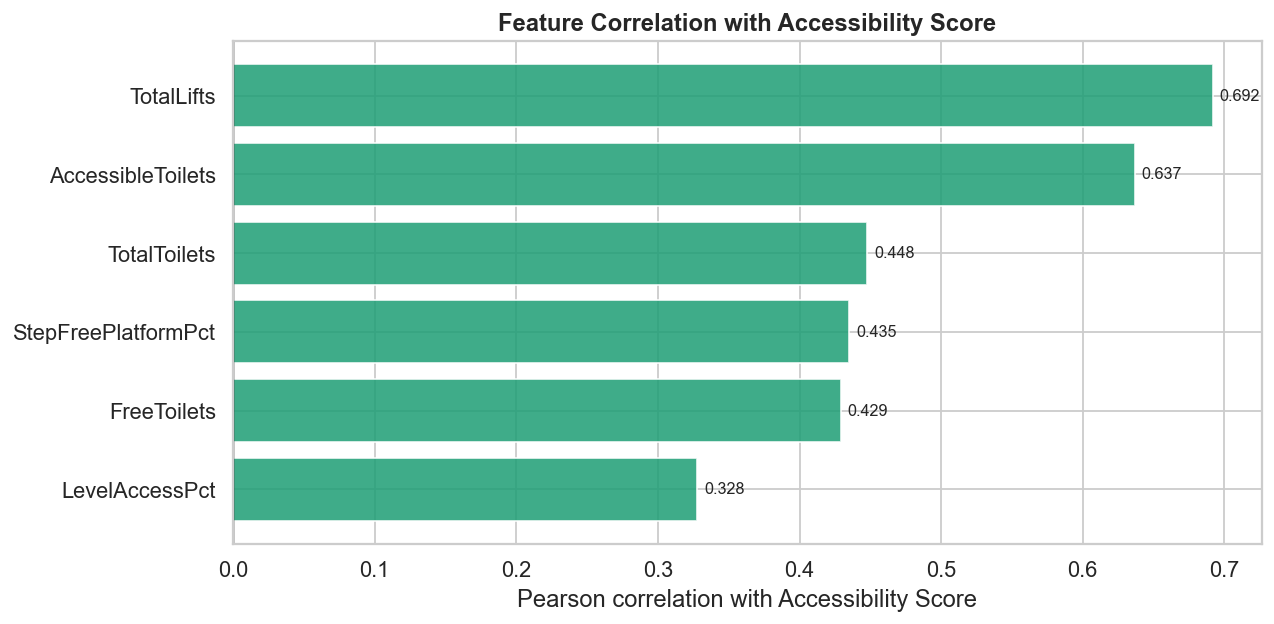

In [5]:
# ── Feature correlation with accessibility score ─────────────────
num_features = ['TotalLifts','StepFreePlatformPct','AccessibleToilets',
                'LevelAccessPct','RampRouteCount','StepFreeInterchangeCount',
                'TotalToilets','FreeToilets']

corr = (master[num_features + ['AccessibilityScore']]
        .corr()['AccessibilityScore']
        .drop('AccessibilityScore')
        .sort_values())

fig, ax = plt.subplots(figsize=(10, 5))
colours_c = ['#1D9E75' if v > 0 else '#E24B4A' for v in corr.values]
ax.barh(corr.index, corr.values, color=colours_c, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
for i, v in enumerate(corr.values):
    ax.text(v + 0.005 if v >= 0 else v - 0.005, i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=9)
ax.set_xlabel('Pearson correlation with Accessibility Score')
ax.set_title('Feature Correlation with Accessibility Score', fontweight='bold')
plt.tight_layout()
plt.show()

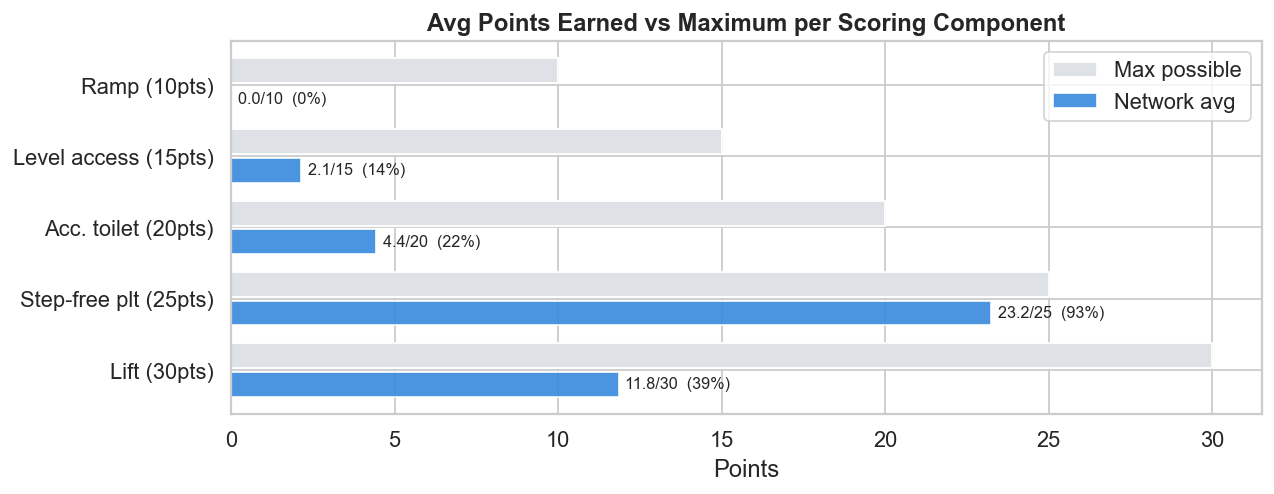

In [6]:
# ── Score breakdown — avg points earned per component ────────────
components = {
    'Lift (30pts)':          (master['HasLift'] * 30).mean(),
    'Step-free plt (25pts)': (master['StepFreePlatformPct'] * 25).mean(),
    'Acc. toilet (20pts)':   (master['HasAccessibleToilet'] * 20).mean(),
    'Level access (15pts)':  (master['LevelAccessPct'] * 15).mean(),
    'Ramp (10pts)':          (master['HasRamp'] * 10).mean(),
}
max_pts = [30, 25, 20, 15, 10]
labels  = list(components.keys())
actuals = list(components.values())

fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(labels))
ax.barh([i+0.2 for i in x], max_pts, 0.35, label='Max possible', color='#dee2e6', edgecolor='white')
ax.barh([i-0.2 for i in x], actuals, 0.35, label='Network avg',  color='#378ADD', edgecolor='white', alpha=0.9)
ax.set_yticks(list(x))
ax.set_yticklabels(labels)
ax.set_xlabel('Points')
ax.set_title('Avg Points Earned vs Maximum per Scoring Component', fontweight='bold')
ax.legend()
for i, (a, m) in enumerate(zip(actuals, max_pts)):
    ax.text(a + 0.2, i - 0.2, f'{a:.1f}/{m}  ({a/m*100:.0f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

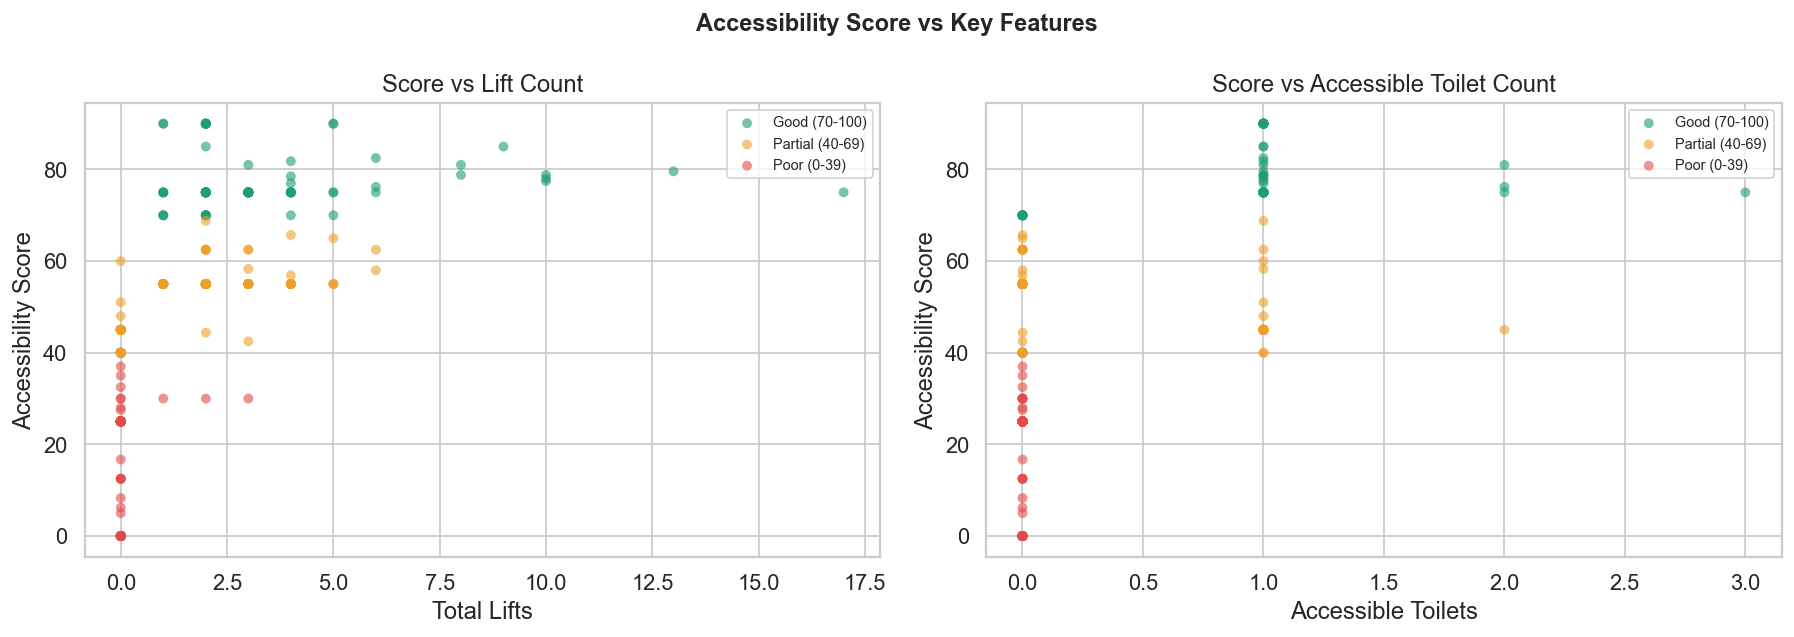

In [7]:
# ── Scatter: score vs lifts & score vs toilets ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for band in BAND_ORDER:
    sub = master[master['AccessibilityBand'] == band]
    axes[0].scatter(sub['TotalLifts'], sub['AccessibilityScore'],
                    c=COLOURS[band], label=band, alpha=0.6, s=30, edgecolors='none')
    axes[1].scatter(sub['AccessibleToilets'], sub['AccessibilityScore'],
                    c=COLOURS[band], label=band, alpha=0.6, s=30, edgecolors='none')
for ax, xl, t in zip(axes,
    ['Total Lifts', 'Accessible Toilets'],
    ['Score vs Lift Count', 'Score vs Accessible Toilet Count']):
    ax.set_xlabel(xl); ax.set_ylabel('Accessibility Score')
    ax.set_title(t); ax.legend(fontsize=8)
plt.suptitle('Accessibility Score vs Key Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# ── Critical gap stations ────────────────────────────────────────
# Zone 1 & 2 stations with zero accessibility score
critical = master[
    (master['AccessibilityScore'] == 0) &
    (master['PrimaryZone'].isin(['1','2']))
][['Name','FareZones','LinesServed','AccessibilityScore',
   'TotalLifts','HasAccessibleToilet','NationalRailInterchange']].sort_values('Name')

print(f'Zone 1-2 stations with ZERO accessibility score: {len(critical)}')
display(critical.reset_index(drop=True))

Zone 1-2 stations with ZERO accessibility score: 2


,Name,FareZones,LinesServed,AccessibilityScore,TotalLifts,HasAccessibleToilet,NationalRailInterchange
0,Loughborough Junction,2,national-rail,0.0,0,0,False
1,Nunhead,2,national-rail,0.0,0,0,False


In [9]:
# ── Summary findings ────────────────────────────────────────────
print('=' * 50)
print('  ACCESSIBILITY GAP — KEY FINDINGS')
print('=' * 50)
findings = [
    f'{master["HasLift"].mean()*100:.0f}% of stations have any lift',
    f'{master["HasAccessibleToilet"].mean()*100:.0f}% of stations have an accessible toilet',
    f'{(master["AccessibilityBand"]=="Poor (0-39)").mean()*100:.0f}% of stations rated Poor',
    f'Average score is {master["AccessibilityScore"].mean():.1f}/100 — below Partial threshold',
    f'Lifts drive the score most (corr = {master[["TotalLifts","AccessibilityScore"]].corr().iloc[0,1]:.2f})',
]
for f in findings:
    print(f'  • {f}')

  ACCESSIBILITY GAP — KEY FINDINGS
  • 39% of stations have any lift
  • 22% of stations have an accessible toilet
  • 49% of stations rated Poor
  • Average score is 41.7/100 — below Partial threshold
  • Lifts drive the score most (corr = 0.69)
